## Task 1: Problem Identification

This dataset represents an Image Classification problem.

The goal is to classify product surface images into one of four categories:

normal
scratch
dent
stain

Image classification is appropriate because:

Each image belongs to only one class.
The model predicts a single label for the entire image.
The dataset contains labeled folders representing different defect categories.

This type of problem is commonly solved using Convolutional Neural Networks (CNNs) because CNNs are highly effective at learning visual patterns from images.

## Task 2: Dataset Exploration

In [1]:
classes = ['dent', 'stain', 'normal', 'scratch']

In [2]:
print("Number of classes:", len(classes))

Number of classes: 4


In [4]:
import os

dataset_path = r"C:\Users\LENOVO\Desktop\BITS_DOCS\assignmnet6\part_2_cnn_computer_vision\images"

for category in classes:
    path = os.path.join(dataset_path, category)
    print(category, ":", len(os.listdir(path)))

dent : 120
stain : 120
normal : 120
scratch : 120


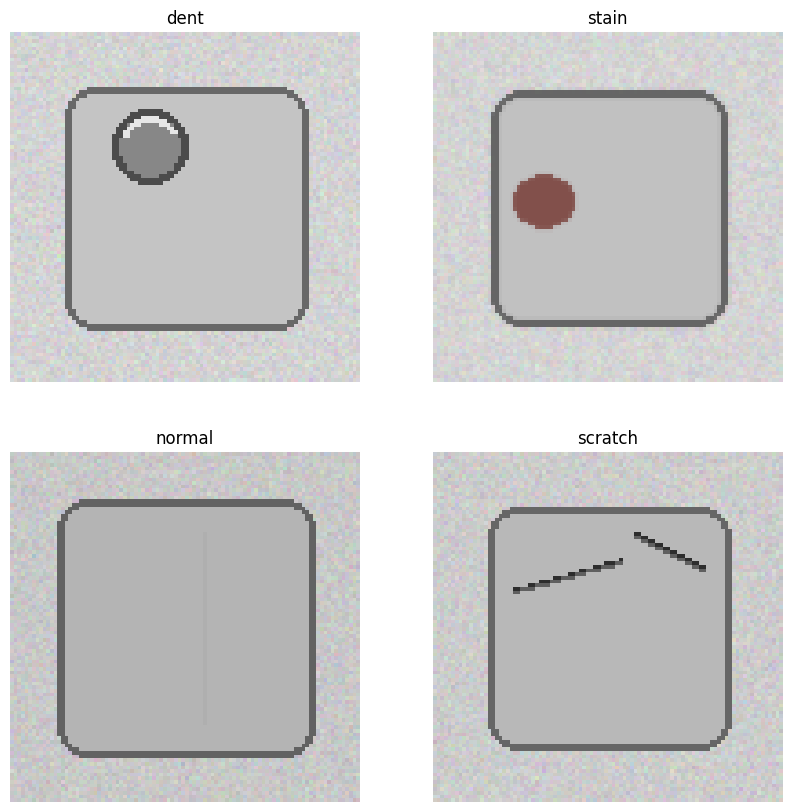

In [5]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

plt.figure(figsize=(10,10))

for i, category in enumerate(classes):

    image_name = os.listdir(os.path.join(dataset_path, category))[0]

    image_path = os.path.join(dataset_path, category, image_name)

    img = load_img(image_path)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis("off")

plt.show()

In [6]:
from PIL import Image

sample_image = Image.open(image_path)

print(sample_image.size)

(96, 96)


## Task 3: Image Preprocessing

In [7]:
(128,128)

(128, 128)

In [8]:
rescale=1./255

In [9]:
validation_split=0.2

## Task 4: CNN Model Creation

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential()

# Convolution Layer 1
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(128,128,3)
))

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 2
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 57600)             0         
                                                                 
 dense (Dense)               (None, 128)               7

## Task 5: Model Training and Evaluation

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    r"C:\Users\LENOVO\Desktop\BITS_DOCS\assignmnet6\part_2_cnn_computer_vision\images",
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    r"C:\Users\LENOVO\Desktop\BITS_DOCS\assignmnet6\part_2_cnn_computer_vision\images",
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


In [13]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
12/12 [==============================] - 10s 738ms/step - loss: 3.0848 - accuracy: 0.2396 - val_loss: 1.3830 - val_accuracy: 0.2500
Epoch 2/10
12/12 [==============================] - 5s 384ms/step - loss: 1.3652 - accuracy: 0.2786 - val_loss: 1.3285 - val_accuracy: 0.2708
Epoch 3/10
12/12 [==============================] - 5s 443ms/step - loss: 1.2486 - accuracy: 0.4427 - val_loss: 1.1216 - val_accuracy: 0.6042
Epoch 4/10
12/12 [==============================] - 5s 443ms/step - loss: 1.0643 - accuracy: 0.5833 - val_loss: 0.9625 - val_accuracy: 0.6146
Epoch 5/10
12/12 [==============================] - 5s 439ms/step - loss: 0.8203 - accuracy: 0.6771 - val_loss: 0.7243 - val_accuracy: 0.7083
Epoch 6/10
12/12 [==============================] - 5s 430ms/step - loss: 0.5823 - accuracy: 0.7943 - val_loss: 0.5572 - val_accuracy: 0.7500
Epoch 7/10
12/12 [==============================] - 6s 533ms/step - loss: 0.4652 - accuracy: 0.8151 - val_loss: 0.4470 - val_accuracy: 0.8333
Epoch

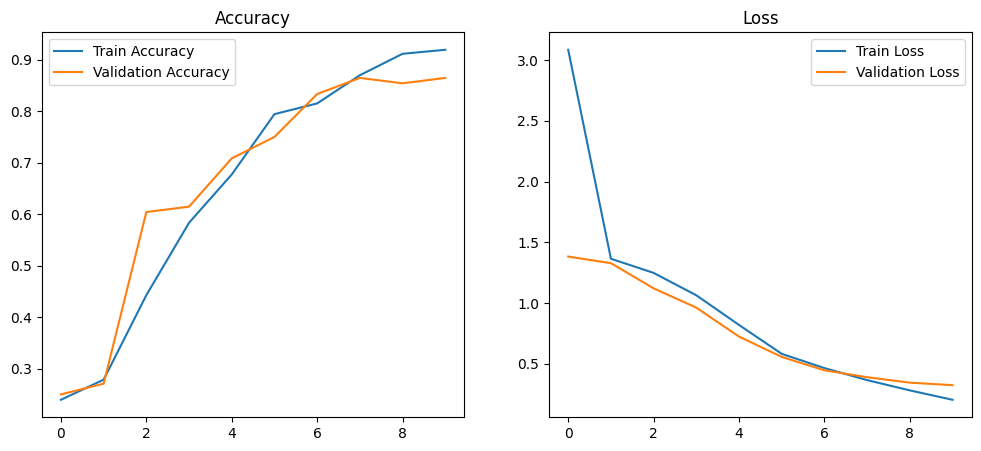

In [15]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")


plt.show()

3/3 [==============================] - 0s 109ms/step


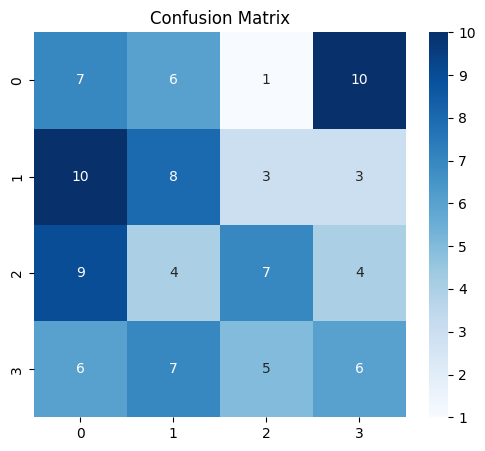

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(val_data.classes, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")


plt.show()

1/1 [==============================] - 0s 28ms/step


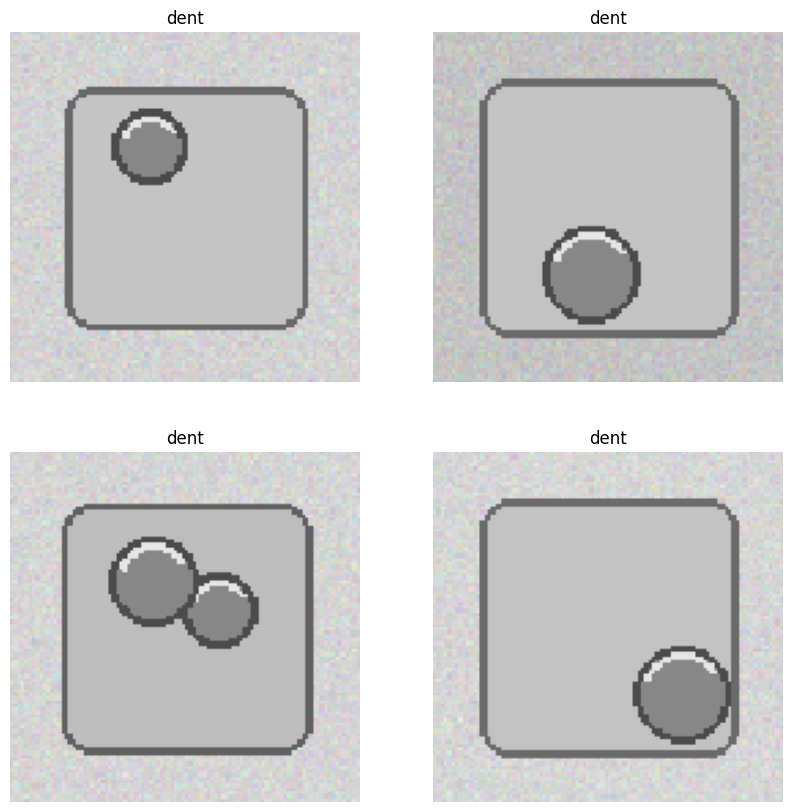

In [19]:
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array

class_names = list(train_data.class_indices.keys())

plt.figure(figsize=(10,10))

for i in range(4):

    img_path = val_data.filepaths[i]

    img = load_img(img_path, target_size=(128,128))

    img_array = img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)

    predicted_class = class_names[np.argmax(pred)]

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(predicted_class)
    plt.axis("off")


plt.show()

## Task 6: CNN Concept Explanation

What is Convolution?

Convolution is the process where filters slide over an image to detect important features such as edges, textures, and shapes.

Why is Pooling Used?

Pooling reduces image dimensions while preserving important features. It helps reduce computation and overfitting.

Why is ReLU Commonly Used?

ReLU introduces non-linearity and helps the network learn complex patterns efficiently. It also speeds up training.

Why are CNNs Better for Images?

CNNs automatically learn spatial and visual features from images, unlike regular neural networks which cannot efficiently capture image patterns.

## Task 7: Business Use Case Mapping

This solution can be used in manufacturing quality inspection.

Example:

Detect scratches on products
Identify dents in metal surfaces
Detect stains or surface contamination
Automatically separate defective and non-defective products

Benefits:

Faster inspection
Reduced manual labor
Improved product quality
Real-time defect detection
Reduced manufacturing cost

Industries:

Automobile manufacturing
Electronics
Steel manufacturing
Packaging industries
Industrial automation